# A/B-тест новой версии страницы оформления дебетовой карты цифрового банка

Честно говоря, я не знаю, как правильно делать отдельный проект для резюме, но подумал, что лишним это точно не будет. Поэтому я решил самостоятельно разобрать продуктовую задачу на примере публичных данных и пройти весь процесс анализа от начала до конца.

---
### Цель
В этом проекте я ставлю перед собой задачу сравнить старую и новую страницу банка и понять, как меняется конверсия после обновления. Мне важно не просто посмотреть на цифры, а разобраться, действительно ли новая версия работает лучше или разница может быть случайной.

Под конверсией я понимаю долю пользователей, которые после захода на страницу начали оформление продукта.

---
### Задачи
В рамках проекта я:
- проверю корректность данных эксперимента;
- сравню конверсию в контрольной и тестовой группах;
- оценю размер изменения;
- проведу статистическую проверку гипотез;
- и сделаю вывод - стоит ли внедрять новую страницу.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Данные взяты отсюда: https://github.com/30lm32/ml-ab-testing

In [6]:
df = pd.read_csv("ab_data.csv")
df.head()

,user_id,timestamp,group,landing_page,converted
0,851104,2017-01-21 22:11:48.556739,control,old_page,0
1,804228,2017-01-12 08:01:45.159739,control,old_page,0
2,661590,2017-01-11 16:55:06.154213,treatment,new_page,0
3,853541,2017-01-08 18:28:03.143765,treatment,new_page,0
4,864975,2017-01-21 01:52:26.210827,control,old_page,1


In [7]:
df.shape

(294478, 5)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294478 entries, 0 to 294477
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   user_id       294478 non-null  int64 
 1   timestamp     294478 non-null  object
 2   group         294478 non-null  object
 3   landing_page  294478 non-null  object
 4   converted     294478 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.2+ MB


In [12]:
pd.crosstab(df["group"], df["landing_page"])

landing_page,new_page,old_page
group,,
control,1928,145274
treatment,145311,1965


## Очистка данных

---
Сейчас мы проверим, есть ли строки, где:
- пользователю назначена группа control, но он видит new_page

или

- назначена treatment, но он видит old_page

Если такие строки есть - их нужно удалить, иначе сравнение будет искажено.

In [10]:
bad = df[
    ((df["group"] == "control") & (df["landing_page"] != "old_page")) |
    ((df["group"] == "treatment") & (df["landing_page"] != "new_page"))
]

bad.shape

(3893, 5)

Это неверные строки, поэтому мы их удаляем

In [11]:
df_clean = df.drop(bad.index).copy()
df_clean.shape

(290585, 5)

Проверяем дубликаты пользователей

In [13]:
df_clean["user_id"].duplicated().sum()

np.int64(1)

In [14]:
df_clean = df_clean.drop_duplicates(subset="user_id")
df_clean.shape

(290584, 5)

## Считаем конверсию в группах

---
Теперь, когда данные очищены и мы уверены, что группы распределены корректно, можно переходить к основной части анализа.

На этом этапе я хочу понять, отличается ли конверсия между контрольной и тестовой группами.

Для этого посчитаем:
- среднюю конверсию (mean)
- количество успешных действий (sum)
- размер каждой группы (count)

In [15]:
df_clean.groupby("group")["converted"].agg(["mean", "sum", "count"])

,mean,sum,count
group,,,
control,0.120386,17489,145274
treatment,0.118808,17264,145310


## Проверка статистической значимости

---
На предыдущем шаге мы увидели, что конверсия в тестовой группе ниже, чем в контрольной.

Однако простого сравнения процентов недостаточно - разница может быть вызвана случайными колебаниями.

Чтобы понять, является ли наблюдаемое отличие статистически значимым, проведём z-тест для сравнения двух долей.

In [19]:
#доли
p1 = 17489 / 145274   #control
p2 = 17264 / 145310   #treatment

#размеры выборок
n1 = 145274
n2 = 145310

#объединённая доля
p_pool = (17489 + 17264) / (145274 + 145310)

#стандартная ошибка
se = (p_pool * (1 - p_pool) * (1/n1 + 1/n2)) ** 0.5

#Z-статистика
z = (p1 - p2) / se
z

1.3109241984234394

---
Полученное значение z = 1.31. В рамках анализа используется двусторонний z-тест для сравнения двух долей при уровне значимости а = 0.05.

Критическое значение для данного уровня значимости составляет +-1.96.

Поскольку |z| = 1.31 < 1.96, нулевая гипотеза не отвергается.

Это означает, что наблюдаемая разница в конверсии между контрольной и тестовой группами не является статистически значимой и может быть вызвана случайными колебаниями.

Иными словами, нельзя утверждать, что новая версия страницы действительно влияет на конверсию - обнаруженное отличие может быть вызвано случайными колебаниями.

## Оценка размера эффекта

---
Несмотря на отсутствие статистической значимости, важно оценить величину наблюдаемого изменения.

Рассчитаем:
- абсолютную разницу конверсии
- относительное изменение

In [21]:
# абсолютная разница
diff_abs = p2 - p1

# относительное изменение
diff_rel = (p2 - p1) / p1

diff_abs, diff_rel

(-0.0015782389853555567, -0.01310978845894809)

## Итоговый вывод

---
В результате анализа было установлено, что конверсия новой версии страницы немного ниже, чем у старой.

Абсолютная разница составила -0.16%, а относительное изменение - около −1.31%.

Однако проведённый z-тест показал, что данная разница не является статистически значимой.

Это означает, что наблюдаемое снижение конверсии может быть обусловлено случайными колебаниями, а не реальным влиянием изменения дизайна страницы.

На основании текущих данных нельзя утверждать, что новая версия страницы ухудшает или улучшает конверсию.

С продуктовой точки зрения это означает, что:
- либо изменение действительно не оказывает заметного эффекта,
- либо эффект слишком мал, чтобы быть обнаруженным на текущем объёме данных.

Таким образом, решение о внедрении новой версии страницы требует дополнительного анализа или продолжения эксперимента.

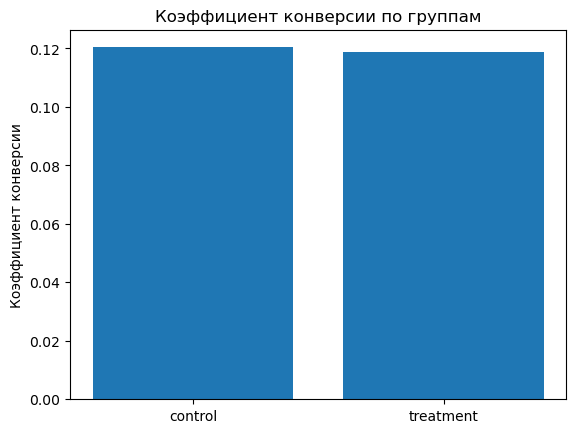

In [36]:
conv = df_clean.groupby("group")["converted"].mean()
plt.bar(conv.index, conv.values)
plt.title("Коэффициент конверсии по группам")
plt.ylabel("Коэффициент конверсии")

plt.show()

Сравнение конверсии в контрольной и тестовой группах.
Наблюдается незначительное снижение конверсии в тестовой группе по сравнению с контрольной.

---